
<!-- # Chương 1: Đánh giá Toàn diện Thuật toán FP-Growth
Dataset: `chess.dat`

Notebook này được chia thành 3 phần kiểm thử độc lập:
1. **Correctness (Tính đúng đắn):** `eval_correctness()` và `vis_correctness()`
2. **Performance (Hiệu năng):** `eval_performance()` và `vis_performance()`
3. **Scalability (Khả năng mở rộng):** `eval_scalability()` và `vis_scalability()` -->

# Evaluate

## Dependencies

In [1]:
# 1. IMPORT CÁC THƯ VIỆN CẦN THIẾT
import Pkg
deps = Pkg.project().dependencies
for pkg in ["DataFrames", "CSV", "Plots"]
    if !haskey(deps, pkg)
        Pkg.add(pkg)
    end
end

using CSV
using DataFrames
using Random
using Plots
using Plots.PlotMeasures
using ProgressMeter
using Statistics
# Thiết lập backend đồ họa mặc định
gr()

include("../src/FPGrowth.jl")
using .FPGrowth
# Load Logger OOP từ file ngoài
include("../src/logger.jl")
# # Load các hàm Hỗ trợ Đánh giá
include("../src/utils.jl")
# include("../src/eval.jl")
using .Utils
# success(logger, "Helper loaded")
logger = Logger()


success(logger, "Dependencies loaded")


[success] Dependencies loaded


In [2]:
Random.seed!(42)
CONFIG = Dict(
    "dataset" => "../data/benchmark/chess.dat/chess.dat",
    "spmf_jar" => "../spmf.jar",
    "java_path" => "C:/Program Files/Microsoft/jdk-21.0.10.7-hotspot/bin/java.exe",
    
    "output_julia" => "../results/chess_julia.txt",
    "output_spmf" => "../results/chess_spmf.txt",
    
    "min_sups" => [0.9, 0.8, 0.7, 0.6],
    "csv_minsup" => "../results/chess_metrics_minsup.csv",
    
    "data_ratios" => [0.4, 0.6, 0.8, 1.0], 
    "fixed_minsup_for_scalability" => 0.7,
    "csv_scalability" => "../results/chess_metrics_scalability.csv"
)

if !isdir("../results") mkdir("../results") end
success(logger, "Config loaded")


[success] Config loaded


## Helpers

In [3]:
# # Load Logger OOP từ file ngoài
# include("../src/logger.jl")
# logger = Logger()

# # Load các hàm Hỗ trợ Đánh giá
# include("../src/utils.jl")
include("../src/eval.jl")
using .Utils
success(logger, "Helper loaded")


[success] Helper loaded


## Correctness Evaluation

In [4]:
# Các hàm eval_correctness, vis_correctness đã được chuyển vào src/eval.jl
# Lưu ý: Các hàm này giờ nhận thêm tham số `logger`
# Ví dụ: eval_correctness(CONFIG, logger)



__________________________________________________
[phase]  CORRECTNESS
__________________________________________________
[info] Kiểm chứng độ chính xác ở ngưỡng MinSup=70.0%
[process] Đang thực thi Julia FPGrowth...
[process] Đang thực thi SPMF Built-in...
[info] Thực hiện so khớp kết quả...

__________________________________________________
[phase]  Visualize
__________________________________________________
[success] chính xác 100% (48731 frequent itemsets)


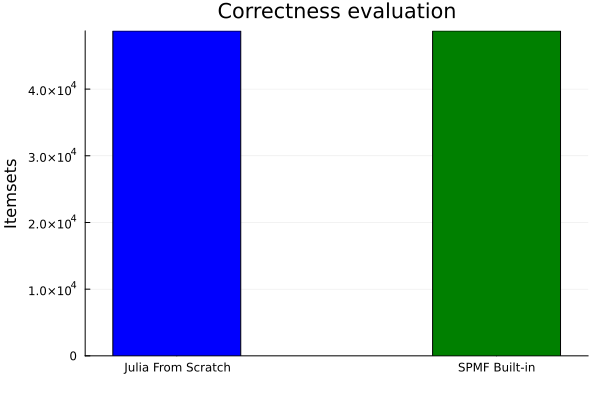

In [5]:
correctness_results = eval_correctness(CONFIG, logger)
vis_correctness(correctness_results, logger)


## Performance Evaluation

In [6]:
# Các hàm eval_performance, vis_performance đã được chuyển vào src/eval.jl
# Lưu ý: Các hàm này giờ nhận thêm tham số `logger`
# Ví dụ: eval_performance(CONFIG, logger)


[process] Đang Warmup JIT Compiler...

__________________________________________________
[phase]  PERFORMANCE
__________________________________________________
[info] Tổng số giao dịch: 3196
[process] Đang thực thi với min_sup = 90.0% (5 lần)...
   [metric] Julia → Time: 0.004s | RAM: 2.3 MB  (median of 5 runs)
   [metric] SPMF  → Time: 0.082s | RAM: 12.38 MB
[process] Đang thực thi với min_sup = 80.0% (5 lần)...
   [metric] Julia → Time: 0.009s | RAM: 5.9 MB  (median of 5 runs)
   [metric] SPMF  → Time: 0.116s | RAM: 19.92 MB


Đang đo hiệu năng...  50%|████████████████              |  ETA: 0:00:05

[process] Đang thực thi với min_sup = 70.0% (5 lần)...


   [metric] Julia → Time: 0.037s | RAM: 28.03 MB  (median of 5 runs)
   [metric] SPMF  → Time: 0.22s | RAM: 20.32 MB
[process] Đang thực thi với min_sup = 60.0% (5 lần)...


Đang đo hiệu năng... 100%|██████████████████████████████| Time: 0:00:10


   [metric] Julia → Time: 0.172s | RAM: 121.04 MB  (median of 5 runs)
   [metric] SPMF  → Time: 0.456s | RAM: 85.17 MB
[success] Saved at ../results/chess_metrics_minsup.csv

__________________________________________________
[phase]  visualize
__________________________________________________


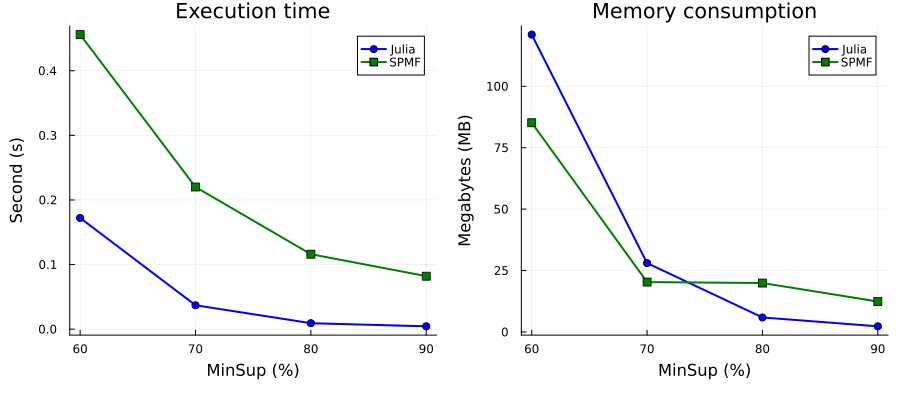

In [7]:
performance_result = eval_performance(CONFIG, logger)
vis_performance(performance_result, logger)


## Scalability Evaluation 

In [8]:
# Các hàm eval_scalability, vis_scalability đã được chuyển vào src/eval.jl
# Lưu ý: Các hàm này giờ nhận thêm tham số `logger`
# Ví dụ: eval_scalability(CONFIG, logger)


[process] Đang Warmup JIT Compiler...

__________________________________________________
[phase]  SCALABILITY
__________________________________________________
[info] Ngưỡng MinSup cố định=70.0%
[process] Data Ratio = 40.0% (1279 giao dịch) ...
   [metric] Julia Time: 1.292s | SPMF Time: 0.903s
[process] Data Ratio = 60.0% (1918 giao dịch) ...


Đang đo độ mở rộng...  50%|███████████████              |  ETA: 0:00:04

   [metric] Julia Time: 0.311s | SPMF Time: 0.39s
[process] Data Ratio = 80.0% (2557 giao dịch) ...


Đang đo độ mở rộng...  75%|██████████████████████       |  ETA: 0:00:02

   [metric] Julia Time: 0.049s | SPMF Time: 0.234s
[process] Data Ratio = 100.0% (3196 giao dịch) ...


Đang đo độ mở rộng... 100%|█████████████████████████████| Time: 0:00:06


   [metric] Julia Time: 0.035s | SPMF Time: 0.244s
[success] Saved at ../results/chess_metrics_scalability.csv

__________________________________________________
[phase]  visualize
__________________________________________________


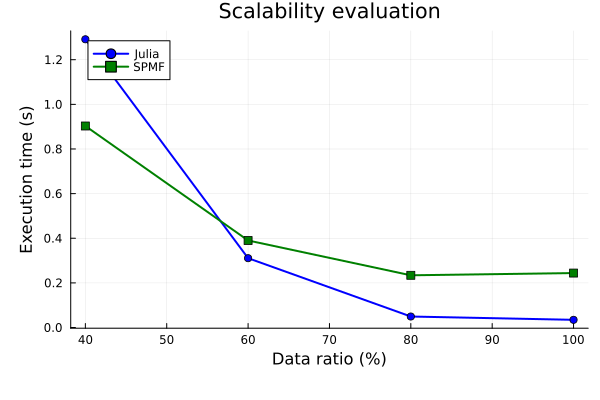

In [9]:
scalability_result = eval_scalability(CONFIG, logger)
vis_scalability(scalability_result, logger)
